# Validación SG 2D con placas impresas (escaneo único, 3 placas)

Replica el pipeline de la validación 2D sintética del capítulo 5 con los defectos físicos impresos (grid 5×4 en placas de 100, 150 y 200 mm).

El escaneo del sensor (C6) contiene las 3 placas en fila. Se procesa el mapa completo 3 veces, una por placa, usando los centros de cada defecto proporcionados manualmente.

**Pasos del sensor**: `STEP_X` (dirección láser, calibrado) y `STEP_Y` (avance por perfil).

**Correcciones sobre `sg_2D.ipynb`**:
- Se resta la base antes del SG: el estimador asume fondo cero (A = -f0).
- sigma con la fórmula de la tesis $\sigma = \sqrt{A/|\kappa|}$.
- **Los NaN del escaneo se rellenan con 0 antes de la convolución SG**: `cv2.filter2D` con `BORDER_REFLECT` propaga NaN de zonas sin datos a toda la imagen de coeficientes.


In [214]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from pathlib import Path

## 1. Configuración

- `PLACAS`: tamaños de placa (mm).
- `RUTA_ESCANEO`: mapa de altura completo (una sola vez), con las 3 placas.
- `RUTA_CENTROS(L)`: CSV por placa con `idx, x_px, y_px` (columna y fila del centro de cada defecto en el mapa completo; origen arriba-izquierda).
- `STEP_X`, `STEP_Y`: pasos del sensor en mm/píxel (X) y mm/perfil (Y).
- Ventanas SG: `WINDOW_SIZE` (real) y `WINDOW_SIZE_SIM` (sintético, paso fino propio).


In [215]:
PLACAS = [100, 150, 200]   # mm
STEP_X = 0.157             # mm/píxel, dirección láser (calibrado)
STEP_Y = 0.0441            # mm/perfil, avance (velocidad cinta / fps)
WINDOW_SIZE = 61           # ventana SG 2D para el escaneo real (en píxeles)
SEED = 42
BASE = 5.0                 # espesor de la placa impresa (mm), para el sintético

BASE_DIR = Path('/home/mario-ross/Proyectos/Tesis/python_pruebas')
RUTA_PARAMS  = lambda L: BASE_DIR / f'stl/parametros_{L}mm.csv'
RUTA_ESCANEO = BASE_DIR / 'escaneos/escaneo_completo.npy'
RUTA_CENTROS = lambda L: BASE_DIR / f'escaneos/centros_{L}mm.csv'


## 2. Ground truth de las 3 placas

In [216]:
gts = {}
for L in PLACAS:
    gts[L] = pd.read_csv(RUTA_PARAMS(L))
    print(f'Placa {L} mm: {len(gts[L])} defectos')
gts[150].head()

Placa 100 mm: 20 defectos
Placa 150 mm: 20 defectos
Placa 200 mm: 20 defectos


,idx,col,row,xc_mm,yc_mm,A_mm,sigma1_mm,sigma2_mm,theta_deg
0,0,0,0,25.0,120.0,2.00,2.250,1.125,0.0
1,1,1,0,50.0,120.0,1.75,3.375,1.500,10.0
2,2,2,0,75.0,120.0,2.50,3.750,1.875,45.0
3,3,3,0,100.0,120.0,1.25,3.000,1.500,15.0
4,4,4,0,125.0,120.0,2.75,4.500,2.250,60.0


## 3. Funciones del pipeline SG 2D

In [217]:
def sg2d_jacobian_projection_cv2(Z, window_size=11):
    assert window_size % 2 == 1, "La ventana debe ser impar"
    hw = window_size // 2
    y_idx, x_idx = np.mgrid[-hw:hw+1, -hw:hw+1]
    regressors = np.stack([
        x_idx**2, y_idx**2, x_idx*y_idx, x_idx, y_idx,
        np.ones_like(x_idx)
    ], axis=-1)
    A = regressors.reshape(-1, 6)
    pseudo = np.linalg.inv(A.T @ A) @ A.T
    kernels = pseudo.reshape(6, window_size, window_size)
    return np.stack([cv2.filter2D(Z, -1, k, borderType=cv2.BORDER_REFLECT)
                     for k in kernels], axis=-1)


def estimate_bump_parameters(centers, coeffs, step_x, step_y):
    """A, sigma1, sigma2 (mm) y theta desde los coeficientes SG."""
    results = []
    for (i0, j0) in centers:
        ii, jj = int(round(i0)), int(round(j0))
        a, b, c, d, e, f0 = coeffs[ii, jj]
        H = np.array([[2*a, c], [c, 2*b]])
        grad = np.array([d, e])
        dx_px, dy_px = -np.linalg.solve(H, grad)
        vi, vj = ii + dy_px, jj + dx_px
        xv, yv = vj - jj, vi - ii
        A_est = abs(-(a*xv**2 + b*yv**2 + c*xv*yv + d*xv + e*yv + f0))
        H_mm = np.array([[2*a/step_x**2, c/(step_x*step_y)],
                         [c/(step_x*step_y), 2*b/step_y**2]])
        k1, k2 = np.linalg.eigvalsh(H_mm)
        w1 = np.sqrt(A_est / max(abs(k1), 1e-12))
        w2 = np.sqrt(A_est / max(abs(k2), 1e-12))
        sigma1, sigma2 = max(w1, w2), min(w1, w2)
        idx = 0 if abs(k1) <= abs(k2) else 1
        principal_vec = np.linalg.eigh(H_mm)[1][:, idx]
        theta = np.arctan2(principal_vec[1], principal_vec[0])
        results.append({'center': (vi, vj), 'A': A_est,
                        'sigma1': sigma1, 'sigma2': sigma2, 'theta': theta})
    return results


def add_rotated_gaussian(Z, x, y, xc, yc, sx, sy, A, th_deg):
    th = np.deg2rad(th_deg)
    X0, Y0 = x - xc, y - yc
    Xr =  np.cos(th) * X0 + np.sin(th) * Y0
    Yr = -np.sin(th) * X0 + np.cos(th) * Y0
    return Z + A * np.exp(-(Xr**2 / (2*sx**2) + Yr**2 / (2*sy**2)))


def build_synthetic(L, gt, step, seed=42, noise_std=0.01):
    """Mapa sintético isotrópico con paso propio (no imita al sensor)."""
    N = int(round(L / step)) + 1
    x = np.linspace(0, L, N)
    y = np.linspace(0, L, N)
    X, Y = np.meshgrid(x, y)
    Z = np.full_like(X, BASE)
    for _, r in gt.iterrows():
        Z = add_rotated_gaussian(Z, X, Y, r.xc_mm, r.yc_mm,
                                 r.sigma1_mm, r.sigma2_mm, -r.A_mm, r.theta_deg)
    if noise_std is not None:
        rng = np.random.default_rng(seed)
        Z += rng.normal(0, noise_std, Z.shape)
    return Z


def mm_to_px(gt, L, N):
    """Centros (fila, columna) en píxel para el sintético isotrópico."""
    px_per_mm = (N - 1) / L
    return [(round(r.yc_mm * px_per_mm), round(r.xc_mm * px_per_mm))
            for _, r in gt.iterrows()]


def build_df(gt, est):
    rows = []
    for i, ((_, r), e) in enumerate(zip(gt.iterrows(), est)):
        rows.append({'idx': r.idx,
                     'A_real': r.A_mm, 'A_est': e['A'],
                     's1_real': r.sigma1_mm, 's1_est': e['sigma1'],
                     's2_real': r.sigma2_mm, 's2_est': e['sigma2'],
                     'sin2t_real': np.sin(2*np.deg2rad(r.theta_deg)),
                     'sin2t_est': np.sin(2*e['theta'])})
    return pd.DataFrame(rows)


def resumen_metricas(dic_dfs, label):
    rows = []
    for L, df in dic_dfs.items():
        if len(df) == 0:
            continue
        fila = {'Placa (mm)': L}
        for col, lab in [('A', 'rho_A'), ('s1', 'rho_s1'), ('s2', 'rho_s2')]:
            real = df[f'{col}_real']; estv = df[f'{col}_est']
            if len(real) > 2 and real.nunique() > 1 and estv.nunique() > 1:
                fila[lab] = np.corrcoef(real, estv)[0, 1]
            else:
                fila[lab] = np.nan
        for col, lab in [('A', 'MAE_A'), ('s1', 'MAE_s1'), ('s2', 'MAE_s2')]:
            real = df[f'{col}_real']; estv = df[f'{col}_est']
            fila[lab] = np.mean(np.abs(real - estv))
        rows.append(fila)
    out = pd.DataFrame(rows).set_index('Placa (mm)')
    print(f'--- {label} ---')
    display(out)
    return out


def corr_plots_multi(dic_dfs, label):
    params = [('A_real', 'A_est', 'Amplitud A (mm)'),
              ('s1_real', 's1_est', 'sigma1 (mm)'),
              ('s2_real', 's2_est', 'sigma2 (mm)'),
              ('sin2t_real', 'sin2t_est', 'sin(2·theta)')]
    colores = {100: 'tab:blue', 150: 'tab:orange', 200: 'tab:green'}
    fig, axes = plt.subplots(2, 2, figsize=(13, 10))
    axes = axes.flatten()
    for ax, (xcol, ycol, lab) in zip(axes, params):
        for L, df in dic_dfs.items():
            if len(df) == 0:
                continue
            ax.scatter(df[xcol], df[ycol], s=45, alpha=0.7,
                       color=colores[L], label=f'{L} mm')
            for _, row in df.iterrows():
                ax.text(row[xcol], row[ycol], str(int(row['idx'])),
                        fontsize=8, color=colores[L], va='bottom', ha='right')
        all_x = pd.concat([df[xcol] for df in dic_dfs.values() if len(df) > 0])
        all_y = pd.concat([df[ycol] for df in dic_dfs.values() if len(df) > 0])
        if len(all_x) > 2 and all_x.nunique() > 1:
            m, b = np.polyfit(all_x, all_y, 1)
            xr = np.linspace(all_x.min(), all_x.max(), 100)
            ax.plot(xr, m*xr + b, 'k--', alpha=0.5, label=f'y={m:.2f}x+{b:.2f}')
        ax.set_xlabel(f'{lab} real')
        ax.set_ylabel(f'{lab} estimado')
        ax.grid(True)
        ax.legend(fontsize='small')
    plt.suptitle(f'Correlación real vs estimado — {label} (3 placas)', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

## 4. Validación sintética (las 3 placas)

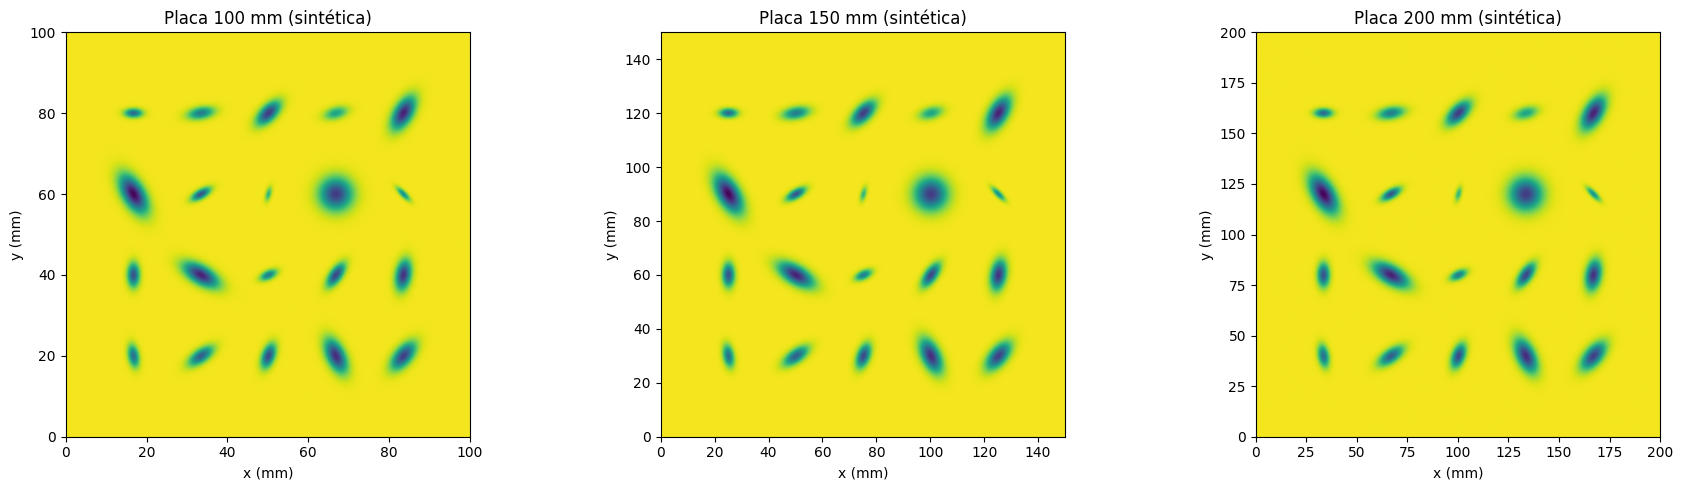

In [218]:
STEP_SIM = 0.04
WINDOW_SIZE_SIM = 41
synth = {}
for L in PLACAS:
    Zs = build_synthetic(L, gts[L], STEP_SIM)
    N = Zs.shape[0]
    Zc = Zs - BASE
    centers_px = mm_to_px(gts[L], L, N)
    coeffs = sg2d_jacobian_projection_cv2(Zc, WINDOW_SIZE_SIM)
    est = estimate_bump_parameters(centers_px, coeffs, STEP_SIM, STEP_SIM)
    synth[L] = {'Z': Zs, 'df': build_df(gts[L], est)}

fig, axes = plt.subplots(1, len(PLACAS), figsize=(6*len(PLACAS), 5))
for ax, L in zip(np.atleast_1d(axes), PLACAS):
    ax.imshow(synth[L]['Z'], cmap='viridis', origin='lower', extent=[0, L, 0, L])
    ax.set_title(f'Placa {L} mm (sintética)')
    ax.set_xlabel('x (mm)'); ax.set_ylabel('y (mm)')
plt.tight_layout()
plt.show()

In [219]:
resumen_synth = resumen_metricas({L: synth[L]['df'] for L in PLACAS}, 'SINTÉTICO')

--- SINTÉTICO ---


,rho_A,rho_s1,rho_s2,MAE_A,MAE_s1,MAE_s2
Placa (mm),,,,,,
100,0.998860,0.994463,0.999096,0.025499,0.150705,0.095251
150,0.999903,0.998485,0.999761,0.006264,0.102762,0.065691
200,0.999987,0.999063,0.999897,0.002297,0.078695,0.053037


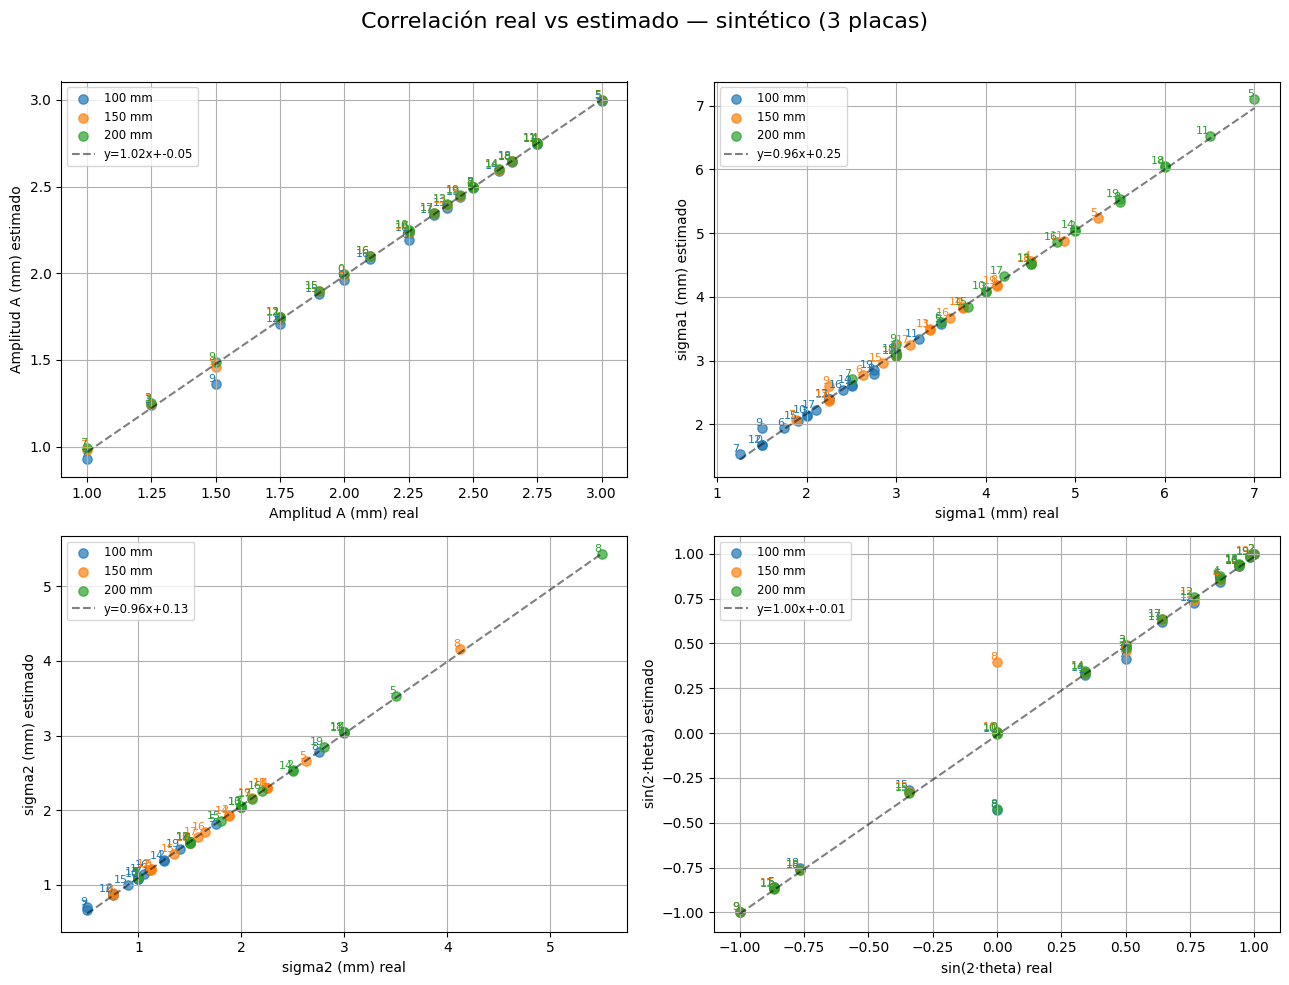

In [220]:
corr_plots_multi({L: synth[L]['df'] for L in PLACAS}, 'sintético')

## 5. Validación con el escaneo real

Resize Y aplicado (cv2): (5444, 3072) (factor 0.4356)
Paso físico por píxel (provisional): 0.1570 mm/px (X e Y)
Escaneo completo: (5444, 3072)
Tendencia por perfil eliminada (RANSAC, umbral 0.15 mm)


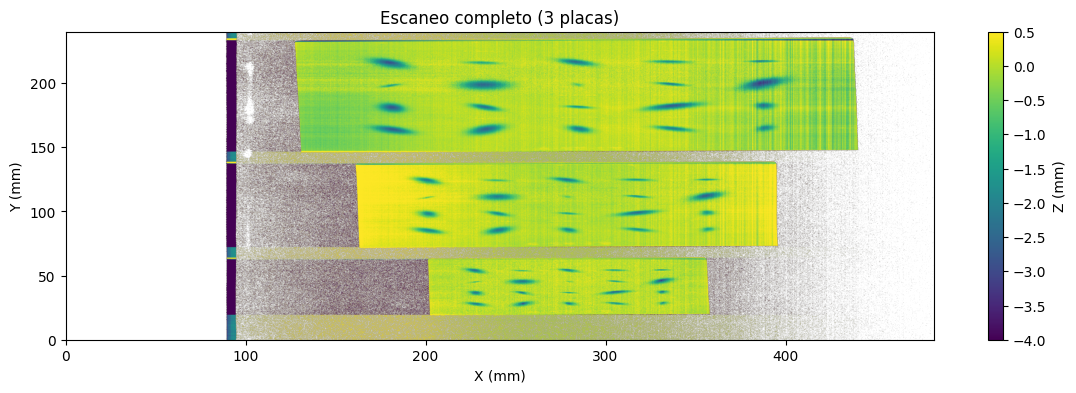

In [221]:
def cargar_escaneo(path):
    ext = path.suffix.lower()
    if ext == '.npy':
        return np.load(path)
    if ext == '.csv':
        return pd.read_csv(path).values.astype(float)
    if ext == '.npz':
        with np.load(path) as z:
            return z[z.files[0]]
    if ext in ('.tif', '.tiff'):
        from PIL import Image
        return np.array(Image.open(path), dtype=float)
    raise ValueError(f'Extensión no soportada: {ext}')


def ransac_line(x, y, n_iter=60, thresh=0.15, min_inliers=20, seed=42):
    """Ajuste de recta robusto (RANSAC) ignorando outliers (defectos)."""
    rng = np.random.default_rng(seed)
    n = len(x)
    best_m, best_b, best_n = 0.0, 0.0, -1
    for _ in range(n_iter):
        i1, i2 = rng.choice(n, 2, replace=False)
        if abs(x[i1] - x[i2]) < 1e-9:
            continue
        m = (y[i1] - y[i2]) / (x[i1] - x[i2])
        b = y[i1] - m * x[i1]
        resid = np.abs(y - (m * x + b))
        nin = int((resid < thresh).sum())
        if nin > best_n:
            best_n, best_m, best_b = nin, m, b
    inliers = np.abs(y - (best_m * x + best_b)) < thresh
    if inliers.sum() < min_inliers:
        return best_m, best_b
    m, b = np.polyfit(x[inliers], y[inliers], 1)
    return m, b


Z_full = cargar_escaneo(RUTA_ESCANEO)
Z_full = Z_full.astype(np.float64)

# ---- Resize del eje Y para píxeles cuadrados ----
# La placa es cuadrada (100/150/200 mm) pero en el escaneo ocupa
# ANCHO_PX en X y ALTO_PX en Y (más resolución en el avance). Se
# comprime Y por ALTO_PX/ANCHO_PX para que el paso físico sea igual
# en ambas direcciones. Los centros del CSV se escalan después (celda 14).
ANCHO_PX = 1960    # px que ocupa la placa en X
ALTO_PX  = 4500    # px que ocupa la placa en Y
RESIZE_Y = ANCHO_PX / ALTO_PX   # factor de compresión del eje Y
# Resize del eje Y con OpenCV (interpolación lineal)
_n_filas_nuevo = int(round(Z_full.shape[0] * RESIZE_Y))
_mask_fin = np.isfinite(Z_full)
_Zfill = np.where(_mask_fin, Z_full, 0.0)
Z_full = cv2.resize(_Zfill, (Z_full.shape[1], _n_filas_nuevo),
                    interpolation=cv2.INTER_LINEAR)
_Zmask = cv2.resize(_mask_fin.astype(np.float32), (Z_full.shape[1], _n_filas_nuevo),
                    interpolation=cv2.INTER_NEAREST) > 0.5
Z_full[~_Zmask] = np.nan
print(f'Resize Y aplicado (cv2): {Z_full.shape} (factor {RESIZE_Y:.4f})')
# Tras el resize los píxeles son cuadrados: mismo paso físico en X e Y.
# Valor provisional (se calibrará con la correlación); usamos el paso X.
STEP_ISO = STEP_X
print(f'Paso físico por píxel (provisional): {STEP_ISO:.4f} mm/px (X e Y)')
print(f'Escaneo completo: {Z_full.shape}')

# ---- Preprocesamiento: eliminar la tendencia (plano) de cada perfil ----
C_INI, C_FIN = 1313, 2525
RANSAC_THRESH = 0.15   # mm
cols_aj = np.arange(C_INI, C_FIN)
col_grid = np.arange(Z_full.shape[1])
Z_proc = Z_full.copy()
for i in range(Z_full.shape[0]):
    seg = Z_full[i, C_INI:C_FIN]
    val = np.isfinite(seg)
    if val.sum() >= 20:
        m, b = ransac_line(cols_aj[val], seg[val], thresh=RANSAC_THRESH)
        Z_proc[i] = Z_full[i] - (m * col_grid + b)
    else:
        Z_proc[i] = np.nan
Z_full = Z_proc
print(f'Tendencia por perfil eliminada (RANSAC, umbral {RANSAC_THRESH} mm)')

# ---- Sustracción de base: mediana del mapa ----
Zc_full = Z_full - np.nanmedian(Z_full)
# Rellenar NaN con 0 para que el SG no propague NaN (BORDER_REFLECT)
Zc_sg = np.where(np.isfinite(Zc_full), Zc_full, 0.0)

# Visualización
plt.figure(figsize=(14, 4))
plt.imshow(Zc_full, aspect='auto', cmap='viridis',
           extent=[0, Zc_full.shape[1]*STEP_X, 0, Zc_full.shape[0]*STEP_Y],
           vmin=-4, vmax=0.5)
plt.xlabel('X (mm)'); plt.ylabel('Y (mm)')
plt.colorbar(label='Z (mm)')
plt.title('Escaneo completo (3 placas)')
plt.show()

In [222]:
reales = {}
for L in PLACAS:
    pc = RUTA_CENTROS(L)
    if pc.exists():
        ctr = pd.read_csv(pc)
        ctr_ok = ctr.dropna(subset=['x_px', 'y_px']).copy()
        ctr_ok = ctr_ok[ctr_ok['x_px'] != '']
        ctr_ok['x_px'] = pd.to_numeric(ctr_ok['x_px'])
        ctr_ok['y_px'] = pd.to_numeric(ctr_ok['y_px'])
        print(f'Placa {L}: {len(ctr_ok)}/{len(ctr)} centros con coordenadas')
        if len(ctr_ok) == 0:
            print(f'  (sin centros, se omite esta placa)')
            continue
        centers_real = [(int(r.y_px*RESIZE_Y), int(r.x_px)) for _, r in ctr_ok.iterrows()]
        idxs = list(ctr_ok['idx'])
        coeffs = sg2d_jacobian_projection_cv2(Zc_sg, WINDOW_SIZE)
        est = estimate_bump_parameters(centers_real, coeffs, STEP_ISO, STEP_ISO)
        gt_ok = gts[L][gts[L]['idx'].isin(idxs)]
        df_ok = build_df(gt_ok, est)
        reales[L] = {'df': df_ok}
        print(f'  defectos evaluados: {sorted(idxs)}')
    else:
        print(f'Placa {L}: AVISO, falta {pc.name}')

Placa 100: 20/20 centros con coordenadas
  defectos evaluados: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Placa 150: 0/20 centros con coordenadas
  (sin centros, se omite esta placa)
Placa 200: 20/20 centros con coordenadas
  defectos evaluados: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]


In [223]:
if reales:
    resumen_real = resumen_metricas({L: reales[L]['df'] for L in reales}, 'REAL')

--- REAL ---


,rho_A,rho_s1,rho_s2,MAE_A,MAE_s1,MAE_s2
Placa (mm),,,,,,
100,0.037327,-0.185158,-0.191147,0.966708,2.687939,2.164650
200,0.187057,-0.131027,-0.413725,0.611425,4.277952,2.663469


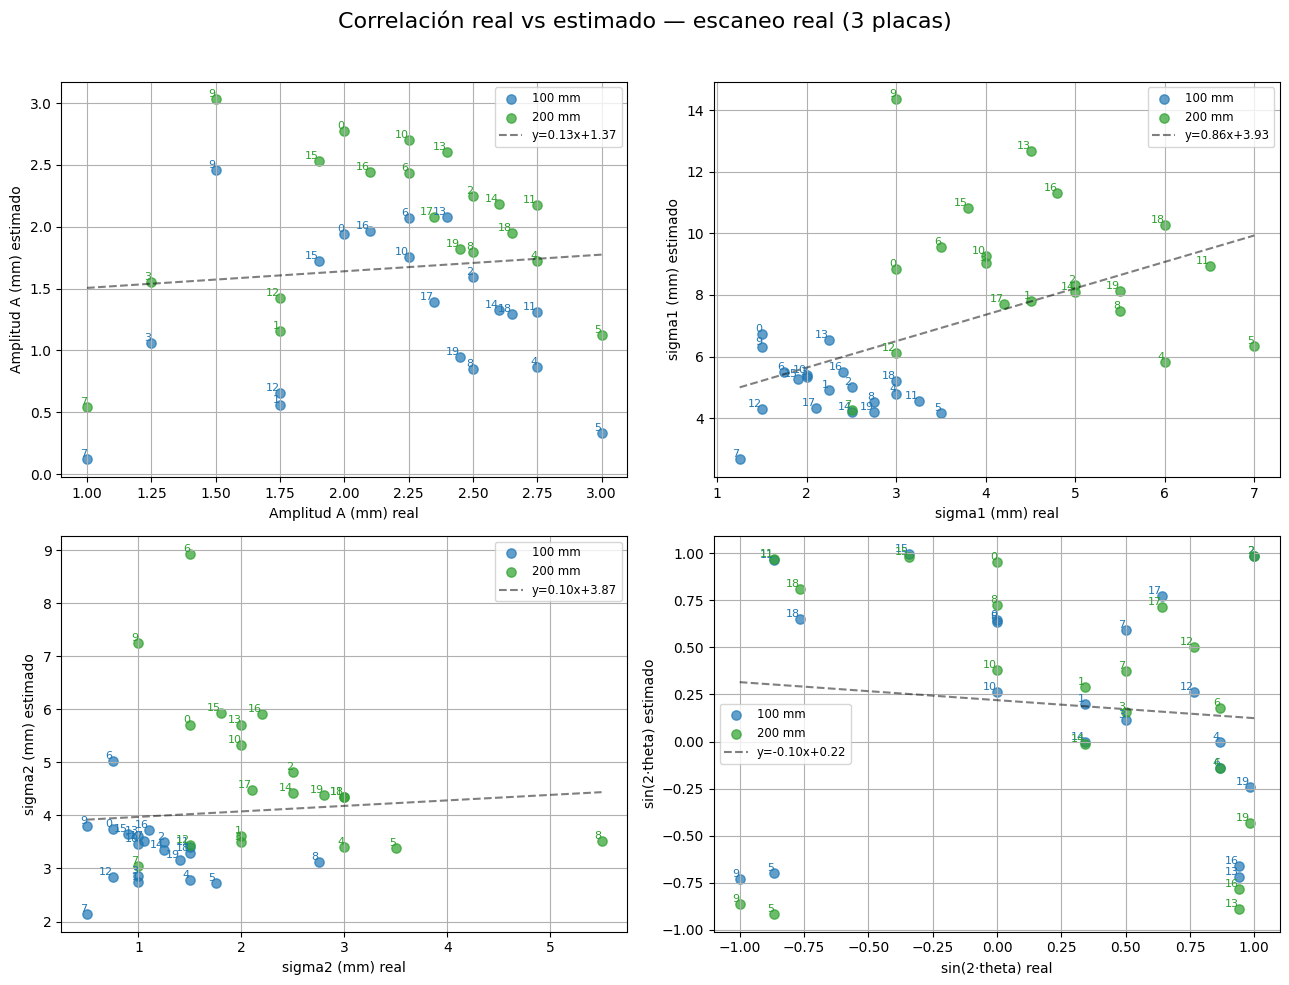

In [224]:
if reales:
    corr_plots_multi({L: reales[L]['df'] for L in reales}, 'escaneo real')

## 6. Depuración del defecto 0 (placa 100)

Réplica exacta del pipeline del notebook original (`sg_2D.ipynb`): todo en píxeles, ventana 61, Hessiano Q = [[a, c/2],[c/2, b]], perfiles a lo largo de los ejes principales con el polinomio del Golay evaluado directamente.


Coefs SG: a=0.002066 b=0.000748 c=-0.001033 d=-0.009225 e=0.013912 f0=-2.025
Vértice (px rel centro): dx=-0.11, dy=-9.38  A_vértice=2.090
Semiejes (px): sigma1=60.57  sigma2=30.51


/tmp/ipykernel_77747/1213730917.py:45: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  if np.cross(v1, v2) < 0:


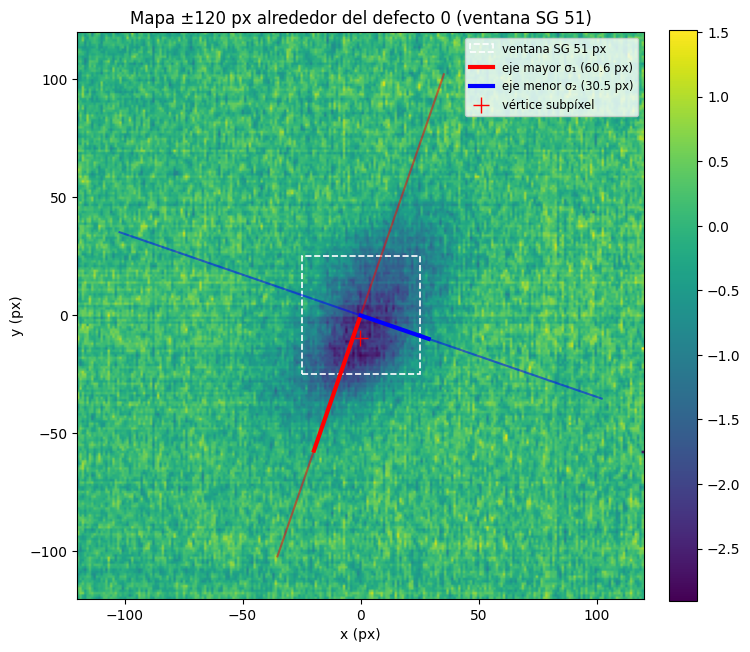

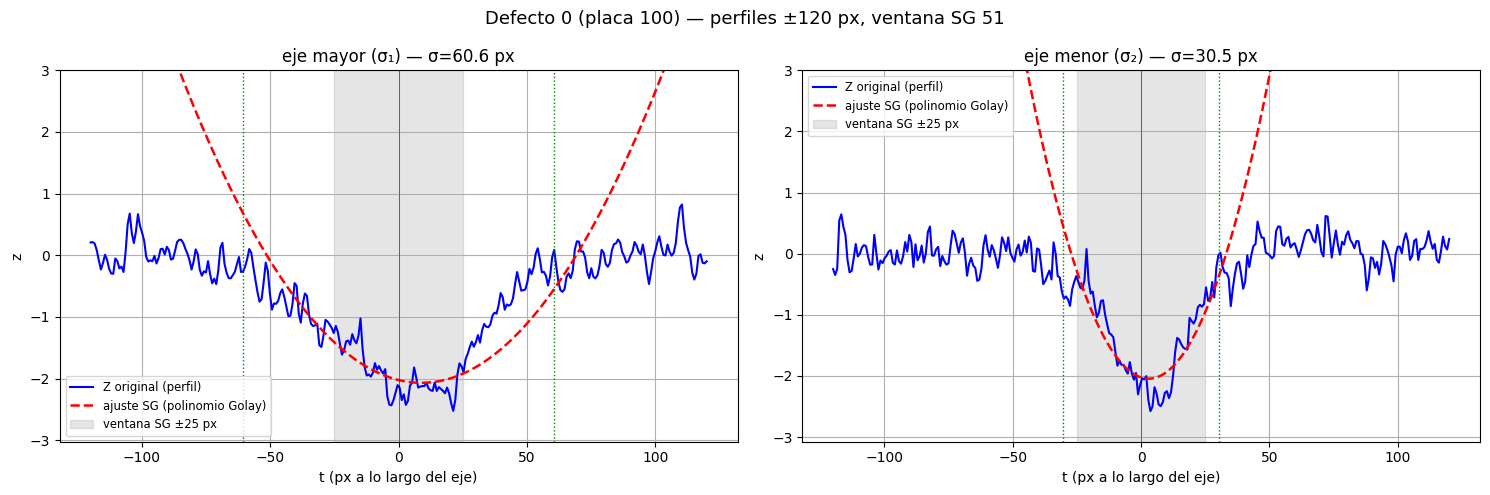

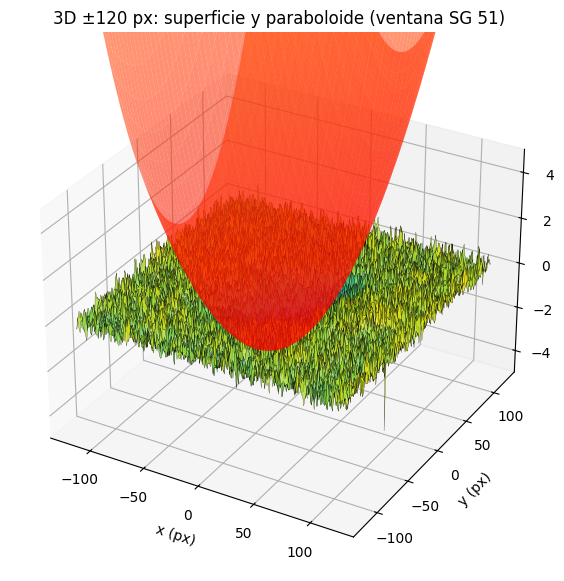

In [225]:
# ---- DEPURACIÓN: defecto 0 (placa 100), ventana SG 31 ----
# El ajuste SG usa la ventana 31, pero las figuras muestran el doble de
# rango (±RANGO px) para ver el entorno del defecto.

from scipy.ndimage import map_coordinates
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

L_DBG = 100
ctr_dbg = pd.read_csv(RUTA_CENTROS(L_DBG))
r_dbg = ctr_dbg[ctr_dbg['idx'] == 0].iloc[0]
y_dbg, x_dbg = int(r_dbg['y_px']*RESIZE_Y), int(r_dbg['x_px'])

W_SG = 51            # ventana SG 2D (ajustada: el defecto cabe bien)
RANGO = 120           # px a cada lado para VISUALIZAR (doble del radio de la ventana)
coeffs_dbg = sg2d_jacobian_projection_cv2(Zc_sg, W_SG)
center = (y_dbg, x_dbg)

def plot_fitted_paraboloid(Z, coeffs, center, window_size=31, zlim=5, samples=300):
    hw = window_size // 2
    i, j = center
    N, M = Z.shape
    if i < hw or i >= N-hw or j < hw or j >= M-hw:
        raise ValueError('Center out of range')

    # Ventana SG (solo para los coeficientes)
    Z_local = Z[i-hw:i+hw+1, j-hw:j+hw+1]
    a, b, c, d, e, f0 = coeffs[i, j, :]

    # Vértice del paraboloide (Newton) y amplitud en el vértice
    Hm = np.array([[2*a, c], [c, 2*b]])
    grad = np.array([d, e])
    dxv, dyv = -np.linalg.solve(Hm, grad)
    xv, yv = dxv, dyv
    A_vert = abs(-(a*xv**2 + b*yv**2 + c*xv*yv + d*xv + e*yv + f0))

    # Hessiano cuadrático Q = [[a, c/2],[c/2, b]].
    # La curvatura (autovalor de Q) es inversamente proporcional a σ²:
    #   κ ∝ 1/σ²  ->  σ = sqrt(A/|κ|)
    # Por tanto, el semieje MAYOR (σ₁) corresponde al autovalor de MENOR
    # magnitud (curvatura más suave), y el menor (σ₂) al de mayor magnitud.
    Q = np.array([[a, c/2], [c/2, b]])
    eigvals, eigvecs = np.linalg.eigh(Q)   # eigvals[0] <= eigvals[1]
    v1 = eigvecs[:, 0]   # menor curvatura -> semieje MAYOR σ₁
    v2 = eigvecs[:, 1]   # mayor curvatura -> semieje MENOR σ₂
    if np.cross(v1, v2) < 0:
        v2 = -v2

    s1 = np.sqrt(A_vert / max(abs(eigvals[0]), 1e-12))   # σ₁ (mayor)
    s2 = np.sqrt(A_vert / max(abs(eigvals[1]), 1e-12))   # σ₂ (menor)

    print(f'Coefs SG: a={a:.6f} b={b:.6f} c={c:.6f} d={d:.6f} e={e:.6f} f0={f0:.3f}')
    print(f'Vértice (px rel centro): dx={xv:.2f}, dy={yv:.2f}  A_vértice={A_vert:.3f}')
    print(f'Semiejes (px): sigma1={s1:.2f}  sigma2={s2:.2f}')

    # ---- 1) Mapa local AMPLIO (rango RANGO) con ejes y ventana SG ----
    Z_amp = Z[i-RANGO:i+RANGO+1, j-RANGO:j+RANGO+1]
    fig, ax = plt.subplots(figsize=(8, 8))
    im = ax.imshow(Z_amp, origin='lower', extent=[-RANGO, RANGO, -RANGO, RANGO], cmap='viridis')
    # ventana SG marcada
    ax.add_patch(plt.Rectangle((-hw, -hw), 2*hw, 2*hw, fill=False, edgecolor='w', lw=1.2, ls='--', label=f'ventana SG {window_size} px'))
    scale = RANGO * 0.9
    for v, s, color, lab in [(v1, s1, 'r', 'eje mayor σ₁'),
                             (v2, s2, 'b', 'eje menor σ₂')]:
        ax.plot([0, v[0]*scale], [0, v[1]*scale], color=color, lw=1.5, alpha=0.5)
        ax.plot([0, -v[0]*scale], [0, -v[1]*scale], color=color, lw=1.5, alpha=0.5)
        ax.plot([0, v[0]*s], [0, v[1]*s], color=color, lw=3, label=f'{lab} ({s:.1f} px)')
    ax.plot(xv, yv, 'r+', ms=12, label='vértice subpíxel')
    ax.set_title(f'Mapa ±{RANGO} px alrededor del defecto 0 (ventana SG {window_size})')
    ax.set_xlabel('x (px)'); ax.set_ylabel('y (px)')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.legend(fontsize='small')
    plt.show()

    # ---- 2) Perfiles en rango amplio (RANGO) ----
    # IMPORTANTE: se muestrea sobre el mapa AMPLIO (Z_amp), no sobre la
    # ventana SG, para ver los datos reales del entorno. El polinomio del
    # Golay se evalúa en todo el rango aunque solo es fiel dentro de la
    # ventana; se marca la ventana en gris.
    def sample_along(v):
        t = np.linspace(-RANGO, RANGO, samples)
        # Z_amp es Z[i-RANGO:i+RANGO+1, j-RANGO:j+RANGO+1]; su centro
        # (píxel (i,j)) está en la posición (RANGO, RANGO) del recorte.
        coords = np.vstack([RANGO + v[1]*t, RANGO + v[0]*t])
        Zorig = map_coordinates(Z_amp, coords, order=1, mode='reflect')
        x = v[0]*t; y = v[1]*t
        Zmod = a*x**2 + b*y**2 + c*x*y + d*x + e*y + f0
        return t, Zorig, Zmod

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    for ax, (v, nom, s) in zip(axes, [(v1, 'eje mayor (σ₁)', s1), (v2, 'eje menor (σ₂)', s2)]):
        t, z_o, z_m = sample_along(v)
        ax.plot(t, z_o, 'b-', lw=1.5, label='Z original (perfil)')
        ax.plot(t, z_m, 'r--', lw=1.8, label='ajuste SG (polinomio Golay)')
        ax.axvspan(-hw, hw, color='gray', alpha=0.2, label=f'ventana SG ±{hw} px')
        ax.axvline(0, color='k', lw=0.6, alpha=0.5)
        for sv in (s, -s):
            ax.axvline(sv, color='g', lw=1, ls=':')
        ax.set_title(f'{nom} — σ={s:.1f} px')
        ax.set_xlabel('t (px a lo largo del eje)'); ax.set_ylabel('z')
        # Eje Y: positivo solo hasta 3; negativo según los datos
        zmin_d = np.nanmin(z_o) if np.isfinite(z_o).any() else -5
        ax.set_ylim(zmin_d - 0.5, 3)
        ax.grid(True); ax.legend(fontsize='small')
    plt.suptitle(f'Defecto 0 (placa 100) — perfiles ±{RANGO} px, ventana SG {window_size}', fontsize=13)
    plt.tight_layout()
    plt.show()

    # ---- 3) Vista 3D amplia ----
    xs3 = np.arange(-RANGO, RANGO+1)
    ys3 = np.arange(-RANGO, RANGO+1)
    Xg3, Yg3 = np.meshgrid(xs3, ys3)
    Z3 = Z[i-RANGO:i+RANGO+1, j-RANGO:j+RANGO+1]
    Z3[~np.isfinite(Z3)] = np.nan
    # paraboloide evaluado en el rango amplio (extrapolado)
    Zf3 = a*Xg3**2 + b*Yg3**2 + c*Xg3*Yg3 + d*Xg3 + e*Yg3 + f0
    fig = plt.figure(figsize=(10, 7))
    ax3 = fig.add_subplot(111, projection='3d')
    ax3.plot_surface(Xg3, Yg3, Z3, cmap='viridis', alpha=0.8, edgecolor='k', linewidth=0.2)
    ax3.plot_surface(Xg3, Yg3, Zf3, cmap='autumn', alpha=0.55, edgecolor='none')
    # limites de la ventana SG en el 3D
    ax3.set_zlim(-zlim, zlim)
    ax3.set_title(f'3D ±{RANGO} px: superficie y paraboloide (ventana SG {window_size})')
    ax3.set_xlabel('x (px)'); ax3.set_ylabel('y (px)'); ax3.set_zlabel('z')
    plt.show()

plot_fitted_paraboloid(Zc_sg, coeffs_dbg, center, window_size=W_SG)

## 7. Comparativa sintético vs real

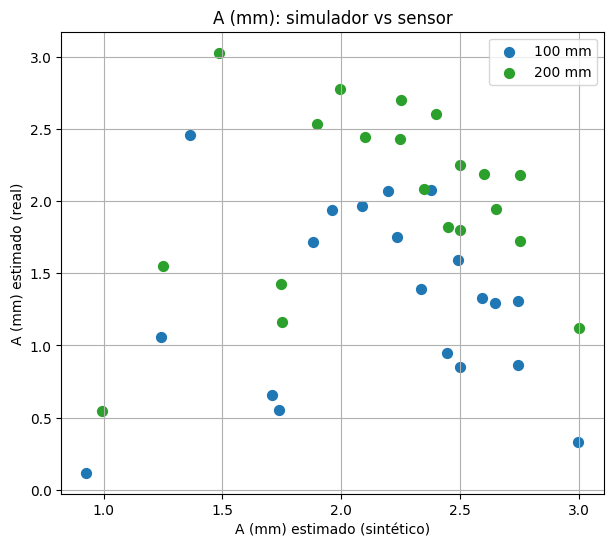

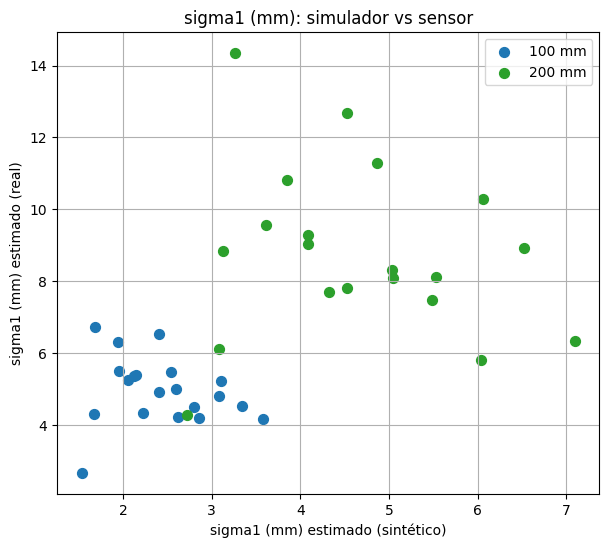

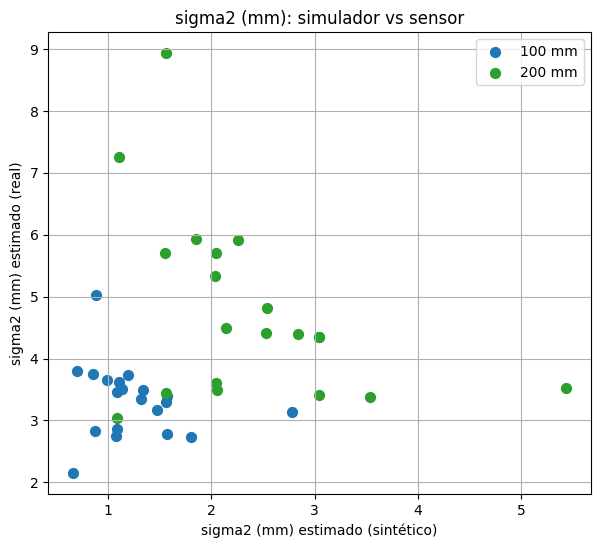

In [226]:
if reales:
    params = [('A', 'A (mm)'), ('s1', 'sigma1 (mm)'), ('s2', 'sigma2 (mm)')]
    colores = {100: 'tab:blue', 150: 'tab:orange', 200: 'tab:green'}
    for col, lab in params:
        plt.figure(figsize=(7, 6))
        for L in PLACAS:
            if L not in reales or len(reales[L]['df']) == 0:
                continue
            s, r = synth[L]['df'], reales[L]['df']
            m = s.merge(r[['idx', f'{col}_est']], on='idx', suffixes=('_s', '_r'))
            xv = m[f'{col}_est_s']; yv = m[f'{col}_est_r']
            plt.scatter(xv, yv, s=50, color=colores[L], label=f'{L} mm')
        plt.xlabel(f'{lab} estimado (sintético)')
        plt.ylabel(f'{lab} estimado (real)')
        plt.title(f'{lab}: simulador vs sensor')
        plt.grid(True)
        plt.legend()
        plt.show()

## 8. Tabla comparativa final

In [227]:
if reales:
    filas = []
    for L in PLACAS:
        if L not in reales or len(reales[L]['df']) == 0:
            continue
        s, r = synth[L]['df'], reales[L]['df']
        for col, lab in [('A', 'A (mm)'), ('s1', 'sigma1 (mm)'), ('s2', 'sigma2 (mm)')]:
            m = s.merge(r[['idx', f'{col}_est']], on='idx', suffixes=('_s', '_r'))
            rho_s = np.corrcoef(m[f'{col}_real'], m[f'{col}_est_s'])[0, 1] if len(m) > 2 and m[f'{col}_est_s'].nunique() > 1 else np.nan
            rho_r = np.corrcoef(m[f'{col}_real'], m[f'{col}_est_r'])[0, 1] if len(m) > 2 and m[f'{col}_est_r'].nunique() > 1 else np.nan
            filas.append({'Placa': f'{L} mm', 'Parámetro': lab, 'n': len(m),
                          'rho_sintético': rho_s, 'rho_real': rho_r,
                          'MAE_sintético (mm)': np.mean(abs(m[f'{col}_real']-m[f'{col}_est_s'])),
                          'MAE_real (mm)': np.mean(abs(m[f'{col}_real']-m[f'{col}_est_r']))})
    display(pd.DataFrame(filas))

,Placa,Parámetro,n,rho_sintético,rho_real,MAE_sintético (mm),MAE_real (mm)
0,100 mm,A (mm),20,0.998860,0.037327,0.025499,0.966708
1,100 mm,sigma1 (mm),20,0.994463,-0.185158,0.150705,2.687939
2,100 mm,sigma2 (mm),20,0.999096,-0.191147,0.095251,2.164650
3,200 mm,A (mm),20,0.999987,0.187057,0.002297,0.611425
4,200 mm,sigma1 (mm),20,0.999063,-0.131027,0.078695,4.277952
5,200 mm,sigma2 (mm),20,0.999897,-0.413725,0.053037,2.663469
